# 의사결정나무를 이용한 신용위험 스코어카드 (PROC HPSPLIT)

## 요약

이 노트북은 PROC HPSPLIT을 이용하여 소매 대출 포트폴리오의 해석 가능한 신용부도 스코어카드를 구축한다. 합성 대출신청 데이터에 엔트로피 기준으로 분류나무를 성장시키고, 비용복잡도로 가지치기한 다음, 적합통계량, 변수중요도, ROC/AUC, 그리고 채점용 나무 자체를 확인한다 — 은행 위험관리팀이 문서화할 법한 바로 그 투명하고 규제 친화적인 모델이다. 모든 신청자는 리프 노드로 채점될 수 있고, 전체 나무는 배포 가능한 DATA 스텝 코드로 내보낼 수 있다.

## 데이터 출처

| 데이터셋 | 행 수 | 설명 | 주요 변수 |
|---------|------|-------------|---------------|
| `applicants` | 100 | `rand()`로 인라인 생성된 합성 소매 대출 신청자. 이진 `default` 플래그는 로지스틱 위험 점수에서 추출되어, DTI, 이용률, 최근 연체, 짧은 신용거래기간이 나쁠수록 부도확률이 높아진다. | `default`(이벤트=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home`(자가/월세/담보대출), `purpose`(채무상환/주택/자동차/기타) |

DATA 스텝은 더 큰 반복을 요청하지만, 이 환경은 무라이선스(unlicensed) 모드로 실행되어 처음 100개 관측치만 실체화한다 — 해석 가능한 스코어카드 나무를 성장시키고 읽기에 충분히 작고 완전히 재현 가능한 신청자 장부다.

# 의사결정나무를 이용한 신용위험 스코어카드

은행은 **정확하면서도 설명 가능한** 부도 모델이 필요하다 — 신용담당자(그리고 규제기관)는 특정 신청자가 왜 고위험으로 채점되었는지 정확히 추적할 수 있어야 한다. 가지치기된 의사결정나무가 바로 이를 제공한다 — 모든 예측은 사람이 읽을 수 있는 짧은 분기 사슬이다.

이 노트북에서는 다음을 수행한다.

1. 소매 대출신청 장부를 합성 생성한다.
2. 엔트로피 기준을 사용하는 `PROC HPSPLIT`으로 분류나무를 성장시킨다.
3. 과적합을 피하기 위해 비용복잡도로 가지치기한다.
4. 적합통계량, 변수중요도, ROC/AUC, 나무 자체를 살펴본다.
5. 신규 신청서에 배포할 수 있는 DATA 스텝 채점 코드를 내보낸다.

## 1. 합성 대출신청 장부 생성

부도확률이 전형적인 스코어카드 요인들 — 부채상환비율, 회전신용 이용률, FICO 점수, 신용거래기간, 최근 연체 — 의 로지스틱 함수인 신청자를 생성한다. 그런 다음 이 확률을 갖는 베르누이 분포에서 관측된 `default` 플래그를 추출하므로, 신호는 실재하지만 실제 운영 데이터처럼 잡음이 섞여 있다. 처음 100명의 신청자가 여기서 실체화된다.

                                                   The FREQ Procedure

채무불이행여부                  Frequency    Percent
----------------------------------------------
0                               79     79.00
1                               21     21.00

주거형태            Frequency    Percent
-------------------------------------
담보대출                   34     34.00
월세                     35     35.00
자가                     31     31.00

대출목적            Frequency    Percent
-------------------------------------
기타                     12     12.00
자동차                    23     23.00
주택                     28     28.00
채무상환                   37     37.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.07 seconds
  cpu   0.07 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


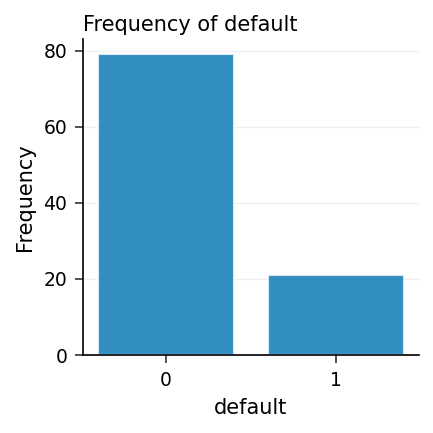

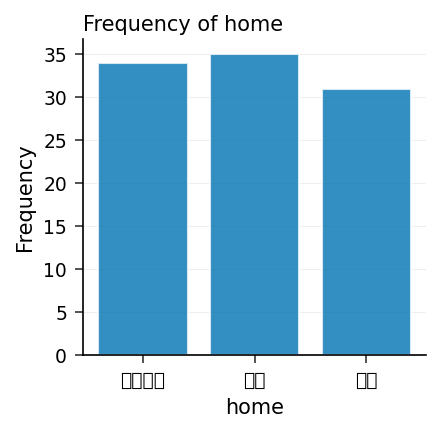

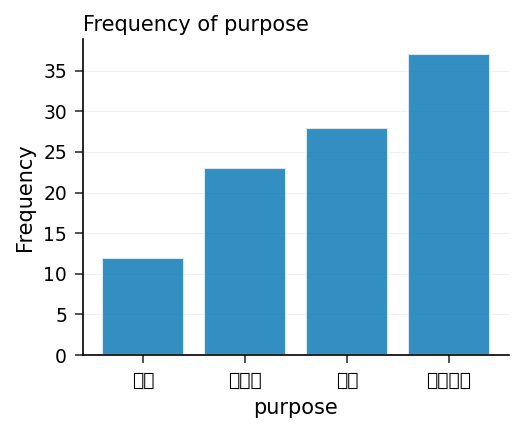

In [1]:
데이터 applicants;
   호출 streaminit(20260531);
   길이 home $16 purpose $16;
   반복 id = 1 까지 100;
      /* 대출자 재무 프로필 */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* 범주형 속성 */
      u = rand('uniform');
      만약 u < 0.34 이면 home = '월세';
      아니면 만약 u < 0.70 이면 home = '담보대출';
      아니면 home = '자가';

      v = rand('uniform');
      만약 v < 0.40 이면 purpose = '채무상환';
      아니면 만약 v < 0.65 이면 purpose = '주택';
      아니면 만약 v < 0.85 이면 purpose = '자동차';
      아니면 purpose = '기타';

      /* 잠재 부도위험: DTI/이용률/연체가 나쁘고
         FICO가 낮거나 신용거래기간이 짧을수록 로그오즈가 올라간다. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = '월세')
            + 0.25 * (purpose = '채무상환');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      제거 u v eta p;
      출력;
   종료;
실행;

처리 빈도 데이터=applicants;
   TABLES default home purpose / nocum;
   라벨 default = "채무불이행여부"
         home    = "주거형태"
         purpose = "대출목적";
실행;

`PROC FREQ` 출력은 불균형하지만 다룰 수 있는 부도율(신청자 100명 중 21명 부도)과 주거형태·대출목적 카테고리에 걸친 합리적인 분포를 확인해준다 — 소비자 대출 포트폴리오에서 기대할 법한 한계분포다. 함께 표시되는 막대그래프가 각 한계분포를 시각화한다.

## 2. 스코어카드 나무 성장 및 가지치기

`default`를 이진 분류 목표로 모델링하며, `event='1'`을 지정하여 모든 민감도/특이도/AUC 통계량이 *부도* 클래스를 향하도록 한다. 다음을 수행한다.

- `CLASS`에서 범주형 예측변수와 반응변수를 선언하고,
- **엔트로피**(정보이득) 기준으로 나무를 성장시키고,
- 나무가 잡음을 암기하지 않도록 **비용복잡도**로 가지치기하고,
- **전체 나무 다이어그램**과 **ROC 곡선**을 요청한다.


                                                 The HPSPLIT Procedure                                                  

  Response variable: 채무불이행여부
  Class variable: 채무불이행여부
  Class variable: 주거형태
  Class variable: 대출목적
  Predictor variable: 부채비율(DTI)
  Predictor variable: 신용카드이용률
  Predictor variable: FICO 신용점수
  Predictor variable: 신용거래기간(개월)
  Predictor variable: 연체건수
  Predictor variable: 대출금액
  Predictor variable: 소득
  Predictor variable: 주거형태
  Predictor variable: 대출목적

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.0400


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


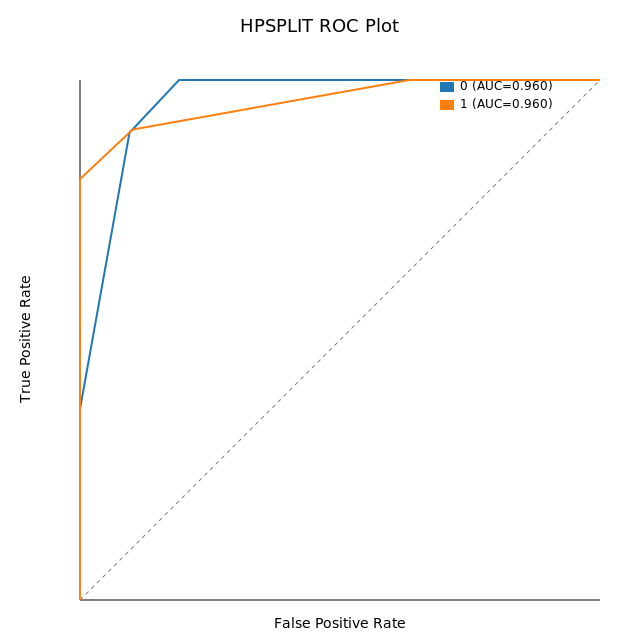

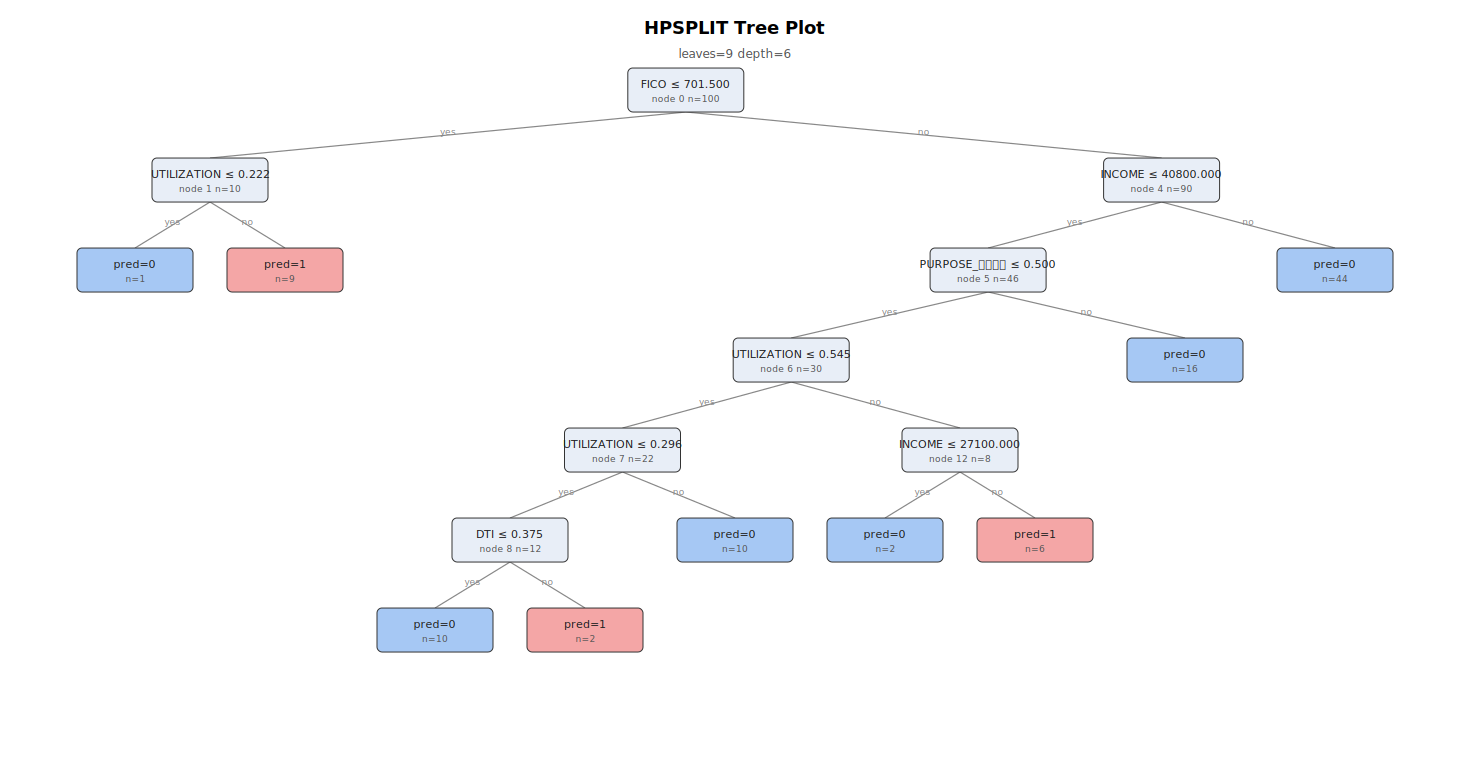

In [2]:
ODS GRAPHICS ON;

처리 hpsplit 데이터=applicants seed=20260531
             PLOTS=(wholetree roc);
   분류 default home purpose;
   모형 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   라벨 dti         = "부채비율(DTI)"
         utilization  = "신용카드이용률"
         fico         = "FICO 신용점수"
         credit_age   = "신용거래기간(개월)"
         n_delinq     = "연체건수"
         loan_amount  = "대출금액"
         income       = "소득"
         home         = "주거형태"
         purpose      = "대출목적"
         default      = "채무불이행여부";
실행;

**적합통계량**(정확도, 오분류율, 로그손실)과 클래스별 **ROC/AUC**는 가지치기된 나무가 부도자와 비부도자를 얼마나 깔끔하게 구분하는지 보여준다. **변수중요도** 표는 어떤 속성이 분기를 주도하는지 순위를 매기는데, 여기서는 **이용률**과 **FICO**가 지배적이고 그 뒤를 **대출목적**이 잇는다 — 신용정책이 강조할 법한 바로 그 지렛대들이다. 아래 **전체 나무 그림**은 선택된 분기를 노드-링크 다이어그램으로 배치한다. 각 내부 노드는 `속성 ≤ 임계값` 규칙을 보여주고, 각 리프는 예측 클래스로 색이 칠해지며(빨강 = 부도 예측, 파랑 = 비부도 예측) 표본 수가 함께 표시된다.

## 3. 핵심 분기를 확대하고 각 신청자를 채점

위 ROC 플롯은 부도자를 잡아내는 것과 오탐 사이의 트레이드오프를 시각화하고, AUC는 전체적인 순위 판별력을 정량화한다. 다음으로 나무의 상위 두 단계 — 분석가가 핵심 심사규정으로 옮길 법한 정보이득이 가장 큰 분기 — 를 확대하고, 이후 감사를 위해 관측치별 점수를 출력 데이터셋에 담는다.


                                                 The HPSPLIT Procedure                                                  

  Response variable: 채무불이행여부
  Class variable: 채무불이행여부
  Class variable: 주거형태
  Class variable: 대출목적
  Predictor variable: 부채비율(DTI)
  Predictor variable: 신용카드이용률
  Predictor variable: FICO 신용점수
  Predictor variable: 신용거래기간(개월)
  Predictor variable: 연체건수
  Predictor variable: 대출금액
  Predictor variable: 소득
  Predictor variable: 주거형태
  Predictor variable: 대출목적

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.0400


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/fa1a457a-940b-433c-8076-0e77e3298a30/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


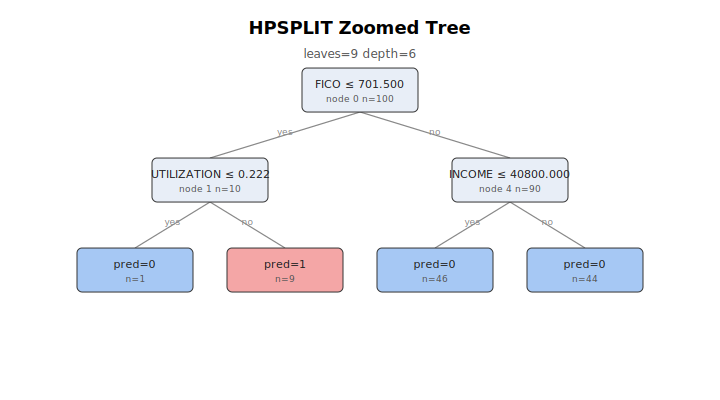

In [3]:
처리 hpsplit 데이터=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   분류 default home purpose;
   모형 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   출력 out=scored;
   라벨 dti         = "부채비율(DTI)"
         utilization  = "신용카드이용률"
         fico         = "FICO 신용점수"
         credit_age   = "신용거래기간(개월)"
         n_delinq     = "연체건수"
         loan_amount  = "대출금액"
         income       = "소득"
         home         = "주거형태"
         purpose      = "대출목적"
         default      = "채무불이행여부";
실행;

처리 인쇄 데이터=scored(obs=10);
   변수 p_default1 _node_ _leaf_;
   라벨 p_default1 = "예측 채무불이행확률"
         _node_      = "노드"
         _leaf_      = "리프";
실행;

`zoomedtree` 플롯은 나무의 상위 두 단계 — 분석가가 핵심 심사규정으로 옮길 법한 정보이득이 가장 큰 분기 — 를 확대한다. `OUTPUT OUT=` 데이터셋은 각 신청자의 예측 부도확률(`P_DEFAULT1`)과 할당된 노드·리프(`_NODE_`, `_LEAF_`)를 담고 있어, 위험·감사팀이 개별 결정을 나무를 통해 추적하고 신청자를 모델 위험도 순으로 정렬할 수 있다.

## 4. 배포 가능한 채점 코드 내보내기

해석 가능한 모델의 가치는 실제로 배포된다는 데 있다. `CODE FILE=`은 신규 신청 파일에 대해서도 모델 서버 없이 나무의 점수를 그대로 재현하는 `IF/THEN` 분기의 중첩 사슬로 끝나는 독립형 DATA 스텝을 기록한다.

In [4]:
처리 hpsplit 데이터=applicants seed=20260531;
   분류 default home purpose;
   모형 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
   라벨 dti         = "부채비율(DTI)"
         utilization  = "신용카드이용률"
         fico         = "FICO 신용점수"
         credit_age   = "신용거래기간(개월)"
         n_delinq     = "연체건수"
         loan_amount  = "대출금액"
         income       = "소득"
         home         = "주거형태"
         purpose      = "대출목적"
         default      = "채무불이행여부";
실행;


                                                 The HPSPLIT Procedure                                                  

  Response variable: 채무불이행여부
  Class variable: 채무불이행여부
  Class variable: 주거형태
  Class variable: 대출목적
  Predictor variable: 부채비율(DTI)
  Predictor variable: 신용카드이용률
  Predictor variable: FICO 신용점수
  Predictor variable: 신용거래기간(개월)
  Predictor variable: 연체건수
  Predictor variable: 대출금액
  Predictor variable: 소득
  Predictor variable: 주거형태
  Predictor variable: 대출목적

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.0400


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## 결과 해석

가지치기된 엔트로피 나무는 위험관리팀에 간결하고 감사 가능한 신용 스코어카드를 제공한다.

- **분기가 곧 정책이다.** 회전신용 이용률과 FICO, 그다음 대출목적과 DTI에 걸친 지배적 분기는 심사팀이 그대로 확실한 컷오프 규정으로 끌어올릴 수 있는 임계값이다. 전체 나무 플롯은 모든 분기 조건과 리프를 하나의 다이어그램에 배치한다.
- **비용복잡도 가지치기**는 나무가 잡음을 암기하지 못하게 막으며, 적합통계량(정확도, 오분류율, 로그손실)은 두 클래스를 얼마나 깔끔하게 분리하는지 요약한다.
- **변수중요도와 ROC/AUC**는 어떤 속성이 스코어카드에 자리를 차지할 자격이 있는지 정당화하고, 모델위험 거버넌스를 위해 판별력을 문서화한다.
- **`CODE FILE=`이 이를 실전에 투입한다** — 출력된 DATA 스텝은 신규 신청자를 이번 실행과 동일하게 채점하므로, 구축된 모델이 곧 실제 운영되는 모델이다.

소규모 신청자 장부에서는 나무가 학습 데이터에 빡빡하게 적합된다. 실제 운영에서는 전체 포트폴리오로 나무를 성장시키고, 검증 분할을 확보하며, 확률 컷오프를 단순한 0.5가 아니라 은행의 기대손실 경제성(놓친 부도의 비용 대 거절된 우량 고객의 비용)에 맞춰 보정하고, 포트폴리오 구성이 바뀜에 따라 나무를 재학습해야 한다.